# CS-421 Machine learning for behavioral data
## Project - GoGymi dataset
### Fatumah binta Doukouré 340969 - Louis Tschanz 315774 - Majandra Garcia 347470

---

## Sub-question 2
#### To what extent does chatbot (GymiTrainer) engagement, in terms of : **frequency, interaction intensity, and feedback patterns**, influence student performance in quizzes and essays?

- **Feature 1:** Chatbot frequency (n_sessions, n_unique_pages) : from chatbot_freq
- **Feature 2:** Interaction intensity (avg_messages_per_session, avg_student_messages, avg_session_duration_s, etc.) : from chatbot_intensity
- **Feature 3:** Feedback scores : from gymitrainer_feedback

---

**This notebook comprises 5 parts:**
1. Loading data
2. Performance Metrix
3. Feature matrix
4. Correlation analysis
5. ML models

In [28]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import ast
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

### 1. Loading data

In [29]:
# Directory
print("Python working directory:", os.getcwd())

data_dir = '../data'
assert os.path.isdir(data_dir), f"File not found: {data_dir}" # check files exist

Python working directory: c:\Users\msgar\OneDrive\Documents\EPFL\Cours\MA4\ML4BD\MLBD_2026\Q2


In [30]:
# 1. User Tables
students = pd.read_csv('{}/students.csv'.format(data_dir))
teachers = pd.read_csv('{}/teachers.csv'.format(data_dir))

In [31]:
# 2. Platform activity tables
pageviews = pd.read_csv('{}/pageviews.csv'.format(data_dir))

In [32]:
# 3. Chatbots specific tables
gymitrainer_feedback = pd.read_csv('{}/gymitrainer_feedback.csv'.format(data_dir))
gymitrainer = pd.read_csv('{}/gymitrainer.csv'.format(data_dir))

In [33]:
# 4. Learning outcomes tables / Perforamance tables
math_results = pd.read_csv('{}/math_results.csv'.format(data_dir))
quiz_results = pd.read_csv('{}/quiz_results.csv'.format(data_dir))
text_results = pd.read_csv('{}/text_results.csv'.format(data_dir))
essay_results = pd.read_csv('{}/essay_results.csv'.format(data_dir))

In [34]:
# 5. Supporting / Mapping / metadata tables // help connect the other tables
course_ids = pd.read_csv('{}/course_ids.csv'.format(data_dir))
math_questions = pd.read_csv('{}/math_questions.csv'.format(data_dir))
quiz_questions = pd.read_csv('{}/quiz_questions.csv'.format(data_dir))
text_questions = pd.read_csv('{}/text_questions.csv'.format(data_dir))
essay_feedback = pd.read_csv('{}/essay_feedback.csv'.format(data_dir))
comments = pd.read_csv('{}/comments.csv'.format(data_dir))

In [35]:
# 6. Events tables
events_dir = f'{data_dir}/events'

events_heartbeat   = pd.read_csv(f'{events_dir}/0.csv', low_memory=False)
events_clicks      = pd.read_csv(f'{events_dir}/c.csv', low_memory=False)
events_gymitrainer = pd.read_csv(f'{events_dir}/g.csv', low_memory=False)
events_media       = pd.read_csv(f'{events_dir}/m.csv', low_memory=False)
events_questions   = pd.read_csv(f'{events_dir}/q.csv', low_memory=False)
events_scroll      = pd.read_csv(f'{events_dir}/s.csv', low_memory=False)

---

### 2. Performance Metrix (what we want to predict)

First we do a quick check on the datasets to see how many students (%) did the math, text, quiz, or essay exercices on GoGymi.

Total unique students: 1781

        table  students_with_data  total_students  coverage_%
 quiz_results                1606            1781        90.2
essay_results                1402            1781        78.7
 text_results                 647            1781        36.3
 math_results                 227            1781        12.7


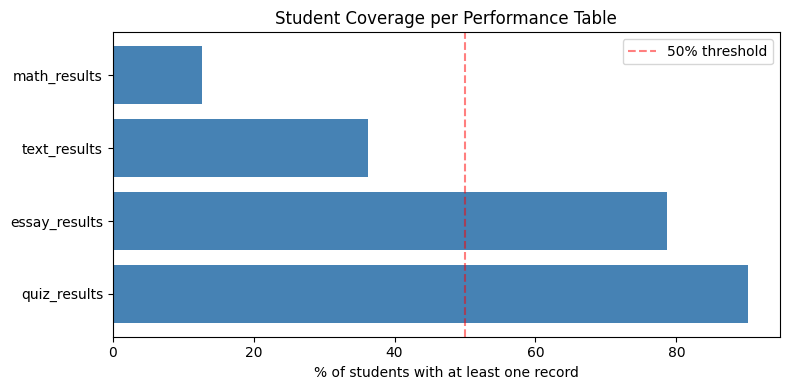

In [36]:
# Check student coverage across all performance tables
total_students = students['user_id'].nunique()
print(f"Total unique students: {total_students}\n")

performance_tables = {
    'essay_results': essay_results,
    'text_results': text_results,
    'quiz_results': quiz_results,
    'math_results': math_results,
}

coverage = []
for name, df in performance_tables.items():
    n_students = df['user_id'].nunique()
    pct = 100 * n_students / total_students
    coverage.append({
        'table': name,
        'students_with_data': n_students,
        'total_students': total_students,
        'coverage_%': round(pct, 1)
    })

coverage_df = pd.DataFrame(coverage).sort_values('coverage_%', ascending=False)
print(coverage_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(coverage_df['table'], coverage_df['coverage_%'], color='steelblue')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.set_xlabel('% of students with at least one record')
ax.set_title('Student Coverage per Performance Table')
ax.legend()
plt.tight_layout()

plt.savefig('1_coverage_performance_tables.png')
plt.show()
plt.close()

Since only `quiz_results` and `essay_results` are above the 50% threshold, we will keep only them to assess the performance (as the other 2 have fewer data). We will then combine the 2 performance scores of `quiz_results` and `essay_results` into a single weighted average per student, as this is simpler to predict. We will use the weight of 0.5 for both (so they have an equal influence).

Now we assess the performance metrix:

In [37]:
# Performance Metric

# 1. Quiz score: average of (points / max_points) per student
quiz_results['norm_score'] = quiz_results['points'] / quiz_results['max_points']
quiz_score = (
    quiz_results
    .groupby('user_id')['norm_score']
    .mean()
    .rename('quiz_score')
)

# 2. Essay score: average of all AI dimension scores per student
# (dimensions are already on a common scale per the data description)
essay_dim_cols = [
    'content__on_topic', 'content__plausible', 'content__convincing_ideas',
    'content__scope', 'content__correct',
    'structure__coherence', 'structure__outline', 'structure__repetition',
    'structure__text_pattern',
    'language__clarity', 'language__spelling', 'language__puncutation',
    'language__word_choice', 'language__sentence_structure', 'language__style'
]

# Average across dimensions first (row-wise), then average across submissions per student
essay_results['mean_dim_score'] = essay_results[essay_dim_cols].mean(axis=1, skipna=True)
essay_score = (
    essay_results
    .groupby('user_id')['mean_dim_score']
    .mean()
    .rename('essay_score')
)

# 3. Combine into one performance DataFrame
performance = pd.concat([quiz_score, essay_score], axis=1)

print("Score ranges before normalization:")
print(performance.describe().round(3))

Score ranges before normalization:
       quiz_score  essay_score
count    1606.000     1402.000
mean        0.649        4.387
std         0.193        0.705
min         0.000        0.000
25%         0.549        4.027
50%         0.677        4.444
75%         0.780        4.846
max         1.000        6.267


We see that the quiz score is already in a 0-1 scale. The essay score's sclare is roughly 0-6, so we normalize by dividing by the max possible value.

Then we do weighted composite score with the weights (0.5 / 0.5).

In [38]:
# 4. Normalize essay_score to 0-1 (scale is 0-6)
performance['essay_score_norm'] = (performance['essay_score'] / 6).clip(0, 1)

# 5. Weighted composite score (0.5 / 0.5)
# NaN handling: if a student has only one score, we use that score alone
performance['performance_score'] = performance[['quiz_score', 'essay_score_norm']].mean(axis=1, skipna=True)

print(performance['performance_score'].describe().round(3))
print(f"\nStudents with full score (quiz + essay): {performance.dropna(subset=['quiz_score', 'essay_score_norm']).shape[0]}")
print(f"Students with only quiz score:           {performance['essay_score'].isna().sum()}")
print(f"Students with only essay score:          {performance['quiz_score'].isna().sum()}")
print(f"Students with both missing:              {performance[['quiz_score','essay_score']].isna().all(axis=1).sum()}")

count    2092.000
mean        0.682
std         0.161
min         0.000
25%         0.614
50%         0.708
75%         0.783
max         1.000
Name: performance_score, dtype: float64

Students with full score (quiz + essay): 916
Students with only quiz score:           690
Students with only essay score:          486
Students with both missing:              0


**The metric looks good:**
- Mean of 0.682 with std 0.161 : nice spread, not heavily skewed
- Scale 0-1 
- No students with both missing (everyone has at least one score)

**Numbers:** 
- 916 students with both : what we want for modeling (most reliable)
- 690 quiz-only : performance score is based on quiz alone for these
- 486 essay-only : performance score is based on essay alone for these
- Total: 2092 : but wait, we had only 1781 unique students earlier ?? $\rightarrow$ see below

In [39]:
# Check who is in performance but not in students.csv
performance_users = set(performance.index)
students_users = set(students['user_id'])

in_perf_not_students = performance_users - students_users
in_students_not_perf = students_users - performance_users

print(f"In performance but not in students.csv: {len(in_perf_not_students)}")
print(f"In students.csv but not in performance: {len(in_students_not_perf)}")

In performance but not in students.csv: 600
In students.csv but not in performance: 289


In [40]:
# Investigate the 600 users in performance but not in students.csv
# Check if they appear in teachers.csv instead
teachers_users = set(teachers['user_id'])

mystery_users = in_perf_not_students
mystery_in_teachers = mystery_users & teachers_users
mystery_nowhere = mystery_users - teachers_users

print(f"Mystery users that are actually teachers: {len(mystery_in_teachers)}")
print(f"Mystery users not in students OR teachers: {len(mystery_nowhere)}")

# Check which tables the mystery users appear in
print("\nMystery user presence across performance tables:")
for name, df in performance_tables.items():
    n = df['user_id'].isin(mystery_users).sum()
    print(f"  {name}: {n} records from mystery users")

# Check the 289 students with no performance data at all
silent_students = in_students_not_perf
print(f"\nOf the 289 students with no performance data:")
print(f"  In pageviews:           {pageviews['user_id'].isin(silent_students).sum()}")
print(f"  In gymitrainer:         {gymitrainer['user_id'].isin(silent_students).sum()}")
print(f"  In comments:            {comments['user_id'].isin(silent_students).sum()}")

Mystery users that are actually teachers: 96
Mystery users not in students OR teachers: 504

Mystery user presence across performance tables:
  essay_results: 4235 records from mystery users
  text_results: 23337 records from mystery users
  quiz_results: 15316 records from mystery users
  math_results: 1788 records from mystery users

Of the 289 students with no performance data:
  In pageviews:           16009
  In gymitrainer:         106
  In comments:            21


**The 600 mystery users:**
- 96 are teachers : makes sense they'd attempt assessments, we exclude them
- 504 are completely unidentified : but they have massive amounts of records (4235 essays, 15316 quizzes, etc.). These could be:
  - Students registered through a different flow (not captured in students.csv)
  - Test accounts
  - Students from a different cohort

**The 289 silent students:**
- They have 16009 pageviews and 106 chatbot conversations. So they were actively using the platform, just never completed assessments. These are real students, just with no performance score.

In [41]:
# Clean modeling population
valid_students = students_users  # 1781 registered students

# Remove teachers from performance
performance = performance[~performance.index.isin(teachers_users)]

# Flag the 504 unidentified users : keep separate for now
performance['is_registered_student'] = performance.index.isin(students_users)

print(f"Registered students with performance score: {performance['is_registered_student'].sum()}")
print(f"Unidentified users with performance score:  {(~performance['is_registered_student']).sum()}")
print(f"Registered students with NO performance:    {len(in_students_not_perf)}")

Registered students with performance score: 1492
Unidentified users with performance score:  504
Registered students with NO performance:    289


In [42]:
# Final clean modeling population: all users except teachers
performance_clean = performance[~performance.index.isin(teachers_users)].drop(columns='is_registered_student')

print(f"Final modeling population: {len(performance_clean)} students")
print(f"  With both quiz + essay:  {performance_clean.dropna(subset=['quiz_score', 'essay_score_norm']).shape[0]}")
print(f"  Quiz only:               {performance_clean['essay_score'].isna().sum()}")
print(f"  Essay only:              {performance_clean['quiz_score'].isna().sum()}")
print(performance_clean['performance_score'].describe().round(3))

Final modeling population: 1996 students
  With both quiz + essay:  893
  Quiz only:               646
  Essay only:              457
count    1996.000
mean        0.686
std         0.153
min         0.000
25%         0.618
50%         0.710
75%         0.783
max         1.000
Name: performance_score, dtype: float64


---

### 3. Feature matrix

For this sub-question we can use these 3 features:
1. Chatbot frequency (number of sessions per student)
2. Interaction intensity (avg messages per session, session duration)
3. Feedback scores

First let's look at the datasets structure.

In [43]:
print(gymitrainer.shape)
print(gymitrainer.dtypes)
print(gymitrainer.head(3))

(11671, 5)
Unnamed: 0      str
user_id       int64
url             str
startTime     int64
content         str
dtype: object
                             Unnamed: 0  user_id  \
0  6cac959f-0127-4685-b271-bfdbfbab1646     2436   
1  84fff78f-ce21-4f4e-8017-8fdf340dbf72     2436   
2  5d7cf731-4ec1-4e14-9841-f8382996c1eb     2436   

                                                 url   startTime  \
0  https://gogymi.ch/tests/wahrscheinlichkeit-pru...  1741461889   
1  https://gogymi.ch/themen/wie-du-das-meiste-aus...  1747897784   
2     https://gogymi.ch/tests/quiz-potenzen-wurzeln/  1747890889   

                                             content  
0  [{'text': 'Hallo! Ich bin Gymitrainer, dein Ma...  
1  [{'text': 'Hallo! Ich bin Andrew Wilson, dein ...  
2  [{'text': 'Hallo! Ich bin Gymitrainer, dein Ma...  


Each row is one conversation thread, so frequency is just the number of rows per student.

#### Feature 1: Chatbot Frequency

In [44]:
# Feature 1: Chatbot Frequency
# Each row in gymitrainer = one conversation thread/session

chatbot_freq = (
    gymitrainer
    .groupby('user_id')
    .agg(
        n_sessions=('Unnamed: 0', 'count'), # total number of chatbot sessions
        n_unique_pages=('url', 'nunique'), # how many different pages they used it on
    )
    .reset_index()
)

print(chatbot_freq.shape)
print(chatbot_freq.describe().round(3))
print(f"\nStudents who used chatbot: {len(chatbot_freq)}")
print(f"Students who never used chatbot: {len(performance_clean) - chatbot_freq['user_id'].isin(performance_clean.index).sum()}")

(1139, 3)
        user_id  n_sessions  n_unique_pages
count  1139.000    1139.000        1139.000
mean   2940.584      10.247           6.688
std    2458.007      16.065           8.073
min      17.000       1.000           0.000
25%    1165.000       2.000           2.000
50%    1662.000       5.000           4.000
75%    6326.500      12.000           8.000
max    7164.000     201.000          61.000

Students who used chatbot: 1139
Students who never used chatbot: 963


- 1139 out of 1996 students used the chatbot (57%) : still usable
- Average of 10 sessions per student, but highly skewed (max 201) : there are some power users
- n_unique_pages min is 0 which is odd (1 session but 0 unique pages?) : worth a quick check $\rightarrow$ below

In [45]:
# Check the 0 unique pages anomaly
print(gymitrainer[gymitrainer['url'].isna() | (gymitrainer['url'] == '')].shape[0])
print(gymitrainer['url'].isna().sum())

489
489


489 rows have no URL : that explains the n_unique_pages = 0 anomaly, not a big deal.

#### Feature 2: Interaction Intensity

In [46]:
# Feature 2: Interaction Intensity

# Parse the content JSON to count messages per session
def parse_content(content_str):
    try:
        messages = ast.literal_eval(content_str)
        n_messages = len(messages)
        n_student = sum(1 for m in messages if not m.get('gymitrainer', True))
        n_bot = sum(1 for m in messages if m.get('gymitrainer', False))
        # Session duration: last message time - first message time (seconds)
        times = [m['time'] for m in messages if 'time' in m]
        duration = (max(times) - min(times)) if len(times) > 1 else 0
        return pd.Series([n_messages, n_student, n_bot, duration])
    except:
        return pd.Series([None, None, None, None])

gymitrainer[['n_messages', 'n_student_messages', 'n_bot_messages', 'session_duration_s']] = (
    gymitrainer['content'].apply(parse_content)
)

print(gymitrainer[['n_messages', 'n_student_messages', 'n_bot_messages', 'session_duration_s']].describe().round(3))

       n_messages  n_student_messages  n_bot_messages  session_duration_s
count   11671.000           11671.000       11671.000        1.167100e+04
mean       11.597               5.963           5.635        8.906941e+03
std        15.775               7.902           8.018        1.969464e+05
min         0.000               0.000           0.000        0.000000e+00
25%         2.000               1.000           1.000        1.000000e+01
50%         6.000               3.000           3.000        1.460000e+02
75%        14.000               7.000           7.000        6.655000e+02
max       431.000             215.000         216.000        1.339607e+07


- Average 11.6 messages per session, reasonable
- session_duration std is enormous (1.97e+05) and max is 1.34e+07 seconds (~155 days) : clearly some sessions were never closed, so the "last message time" is garbage for those
- Median of 146 seconds (2.4 min) looks more realistic
- Some sessions have 0 messages : likely empty/failed sessions

#### Feature 3: Interaction Intensity

In [47]:
# Feature 3: Feedback scores from gymitrainer_feedback

# Quick check of dataset structure
print(gymitrainer_feedback.shape)
print(gymitrainer_feedback.dtypes)
print(gymitrainer_feedback.head(3))
print(gymitrainer_feedback['score'].describe().round(3))

(331, 4)
Unnamed: 0      int64
thread_id         str
score         float64
comment           str
dtype: object
   Unnamed: 0                             thread_id  score  \
0           0  bea23cf0-d0ad-4681-946b-0f74252a94eb    1.0   
1           1  a6b06938-564d-44cb-bc59-2e4c940ebfc1    0.0   
2           2  a6b06938-564d-44cb-bc59-2e4c940ebfc1    0.0   

                                 comment  
0  Das war ein sehr hilfreicher Feedback  
1         Es ist ein Fehler vorgekommen   
2         Es ist ein Fehler vorgekommen   
count    331.000
mean       0.650
std        0.478
min        0.000
25%        0.000
50%        1.000
75%        1.000
max        1.000
Name: score, dtype: float64


The score is binary (0 or 1) and only 331 records, that is quite sparse. The thread_id links to gymitrainer's index column (Unnamed: 0). Let's aggregate to student level:

In [48]:
# Feature 3: Feedback scores
# First link thread_id -> user_id via gymitrainer
feedback_with_user = gymitrainer_feedback.merge(
    gymitrainer[['Unnamed: 0', 'user_id']],
    left_on='thread_id',
    right_on='Unnamed: 0',
    how='left'
)

chatbot_feedback = (
    feedback_with_user
    .groupby('user_id')
    .agg(
        n_feedbacks_given=('score', 'count'), # how many times they rated
        avg_feedback_score=('score', 'mean'), # satisfaction rate (0-1)
    )
    .reset_index()
)

print(chatbot_feedback.describe().round(3))
print(f"\nStudents who gave feedback: {len(chatbot_feedback)}")
print(f"Students who never gave feedback: {1996 - len(chatbot_feedback)}")

        user_id  n_feedbacks_given  avg_feedback_score
count   134.000            134.000             134.000
mean   3245.575              2.112               0.679
std    2608.978              2.006               0.412
min     127.000              1.000               0.000
25%    1196.500              1.000               0.375
50%    1765.500              1.000               1.000
75%    6432.250              2.750               1.000
max    7160.000             15.000               1.000

Students who gave feedback: 134
Students who never gave feedback: 1862


We can note that avg_feedback_score will likely be weak given only 134 students have it (6.7% coverage). But we keep it anyway and we will let the model decide later on the features to keep or not.

#### Merging all features into 1 feature matrix:

In [49]:
# Aggregate Feature 2 to student level (one row per student)
chatbot_intensity = (
    gymitrainer
    .groupby('user_id')
    .agg(
        avg_messages_per_session=('n_messages', 'mean'),
        avg_student_messages=('n_student_messages', 'mean'),
        avg_bot_messages=('n_bot_messages', 'mean'),
        total_messages=('n_messages', 'sum'),
        avg_session_duration_s=('session_duration_s', 'median'),  # median to avoid outlier sessions
        max_messages_session=('n_messages', 'max'),               # proxy for deepest engagement
    )
    .reset_index()
)

# Merge all 3 features into one student-level matrix
chatbot_features = (
    chatbot_freq
    .merge(chatbot_intensity, on='user_id', how='outer')
    .merge(chatbot_feedback, on='user_id', how='outer')
)

# Merge with performance score
sq2_data = chatbot_features.merge(
    performance_clean[['performance_score']],
    left_on='user_id',
    right_index=True,
    how='inner'
)

print(sq2_data.shape)
print(sq2_data.isnull().sum())

(1033, 12)
user_id                       0
n_sessions                    0
n_unique_pages                0
avg_messages_per_session      0
avg_student_messages          0
avg_bot_messages              0
total_messages                0
avg_session_duration_s        0
max_messages_session          0
n_feedbacks_given           903
avg_feedback_score          903
performance_score             0
dtype: int64


- 0 missing for all chatbot features : because we used outer merge, everyone in chatbot_freq has all intensity features (they come from the same gymitrainer table).
- 903 missing for feedback features : out of 1033 students, only 134 gave feedback (as we saw earlier). This is expected and fine.
- 1033 students total : this is the intersection of students who used the chatbot AND have a performance score, makes sense.

In [50]:
# Impute missing feedback with 0 (student never gave feedback = no feedback)
sq2_data['n_feedbacks_given'] = sq2_data['n_feedbacks_given'].fillna(0)
sq2_data['avg_feedback_score'] = sq2_data['avg_feedback_score'].fillna(0)

print(f"Final sq2 dataset: {sq2_data.shape}")
print(f"Missing values: {sq2_data.isnull().sum().sum()}")

Final sq2 dataset: (1033, 12)
Missing values: 0


---

### 4. Correlation analysis

This will show which chatbot features are positively vs negatively correlated with performance.

avg_session_duration_s     -0.045
n_feedbacks_given          -0.006
avg_feedback_score         -0.001
n_sessions                  0.027
n_unique_pages              0.046
max_messages_session        0.065
avg_student_messages        0.070
avg_messages_per_session    0.072
avg_bot_messages            0.072
total_messages              0.085
Name: performance_score, dtype: float64


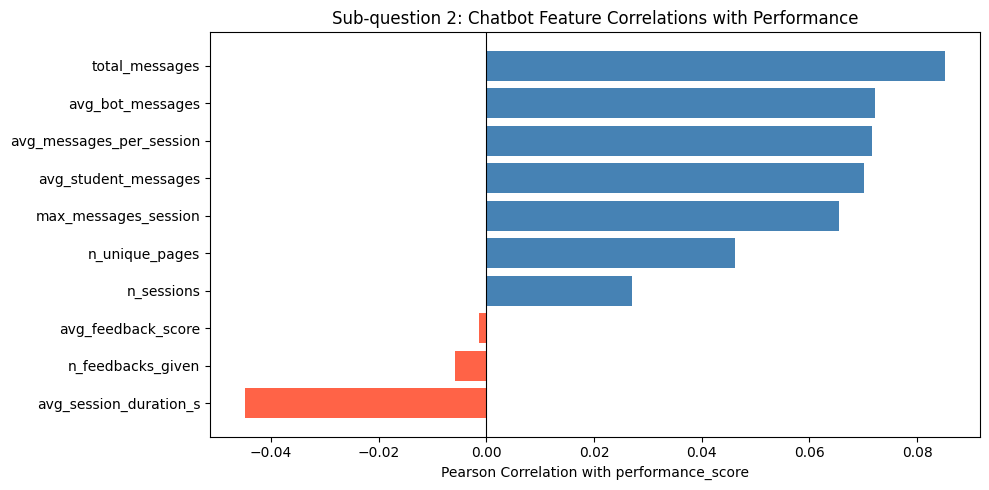

In [55]:
# Correlation of each feature with performance_score
feature_cols = [c for c in sq2_data.columns if c != 'user_id']

corr = sq2_data[feature_cols].corr()['performance_score'].drop('performance_score').sort_values()

print(corr.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if c < 0 else 'steelblue' for c in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with performance_score')
ax.set_title('Sub-question 2: Chatbot Feature Correlations with Performance')
plt.tight_layout()

plt.savefig('2_chatbot_feature_correlations.png')
plt.show()
plt.close()

**Positive correlations (more engagement = better performance):**
- `total_messages` (0.085) and message-intensity features are the strongest predictors
- `avg_messages_per_session` (0.072) > `n_sessions` (0.027), so quality of engagement matters more than quantity of sessions
- `n_unique_pages` (0.046) matters more than `n_sessions` (0.027), so students who used the chatbot across a wider range of topics performed better than those who used it many times but only on the same page.

**Negative correlations:**
- `avg_session_duration_s` (-0.045) : longer sessions correlate with worse performance, which makes intuitive sense: struggling students spend more time per session
- Feedback features (`n_feedbacks_given`, `avg_feedback_score`) near zero : confirms they'll be weak predictors as expected

However, all correlations are very small (max 0.085). This is a hint that the relationship might be non-linear, so tree-based models (Random Forest, XGBoost) will likely perform better than linear regression. Or this could also suggest that chatbot usage alone isn't a strong predictor of performance.

---

### 5. ML models

**Modeling pipeline:**
1. Linear Regression (baseline)
2. Random Forest (captures non-linearity)
3. Compare $R^2$ and feature importance

In [27]:
# Prepare X and y
feature_cols = [c for c in sq2_data.columns if c not in ['user_id', 'performance_score']]
X = sq2_data[feature_cols]
y = sq2_data['performance_score']

# Scale features (important for linear regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Baseline: Linear Regression with 5-fold cross-validation
lr = LinearRegression()
lr_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='r2')
print("Linear Regression:")
print(f"  R\u00b2 per fold: {lr_scores.round(3)}")
print(f"  Mean R\u00b2: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")

# 2. Random Forest with 5-fold cross-validation
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("\nRandom Forest:")
print(f"  R\u00b2 per fold: {rf_scores.round(3)}")
print(f"  Mean R\u00b2: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

Linear Regression:
  R² per fold: [-0.037 -0.072  0.011 -0.245 -0.108]
  Mean R²: -0.090 ± 0.087

Random Forest:
  R² per fold: [-0.075 -0.108 -0.001 -0.132 -0.068]
  Mean R²: -0.077 ± 0.044


Both models have negative $R^2$, which means they perform worse than simply predicting the mean for everyone. This means that Chatbot usage patterns (features) alone cannot predict academic performance. The small positive correlations we saw (max 0.085) were not enough for any model to learn from.

---

## Sub-question 2: Conclusion

**To what extent does chatbot (GymiTrainer) engagement influence student performance?**

- 1,139 out of 1,996 students (57%) used the GymiTrainer chatbot at least once
- Chatbot engagement features show very weak positive correlations with performance 
  (max r=0.085 for `total_messages`), except `avg_session_duration_s` which is 
  slightly negative (r=-0.045)
- Quality of engagement matters more than quantity: `avg_messages_per_session` (r=0.072) 
  is a stronger signal than `n_sessions` (r=0.027)
- Students who used the chatbot across a wider range of pages performed slightly better 
  than those who used it repeatedly on the same page (`n_unique_pages` r=0.046 > `n_sessions` r=0.027)
- Neither Linear Regression ($R^2$=-0.090) nor Random Forest ($R^2$=-0.077) could predict 
  performance from chatbot features alone — both perform worse than predicting the mean

**Overall answer:** Chatbot engagement patterns have no meaningful direct predictive power on academic performance. This suggests chatbot usage may reflect student struggle, rather than being a driver of success. Students who are stuck tend to engage more, but engagement alone does not translate to better outcomes.